In [8]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

print("Project root:", project_root)

Project root: c:\Users\megha\Desktop\xray-transformers


In [9]:
#IMPORTS:

import torch
import matplotlib.pyplot as plt

from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer
)

from xray.interpretability import DistilBertInterpreter

In [10]:
# LOAD THE HUGGINGFACE MODEL:

# Use GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = DistilBertForSequenceClassification.from_pretrained(
    "JDsouza1/distilbert-imdb-sentiment"
).to(device)

tokenizer = DistilBertTokenizer.from_pretrained(
    "JDsouza1/distilbert-imdb-sentiment"
)

print("Model loaded!")

Device: cpu


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 12958.84it/s]


Model loaded!


In [11]:
# CREATE THE INTERPRETER:

interpreter = DistilBertInterpreter(
    model,
    tokenizer,
    device
)

# Compare Attribution Stability:

In [27]:
def compare_attribution_stability(text_a, text_b):
    """
    Compare Integrated Gradients explanations between two texts.

    Only words appearing in both texts are compared.
    """

    # Generate attributions
    words_a, scores_a = get_word_attributions(text_a)
    words_b, scores_b = get_word_attributions(text_b)

    # Convert to dictionaries
    scores_a = dict(zip(words_a, scores_a))
    scores_b = dict(zip(words_b, scores_b))

    # Find shared words
    shared_words = sorted(
        set(scores_a) & set(scores_b)
    )

    if len(shared_words) < 2:
        raise ValueError(
            "At least two shared words are required "
            "to calculate correlation."
        )

    # Extract aligned attribution scores
    aligned_a = [
        scores_a[word]
        for word in shared_words
    ]

    aligned_b = [
        scores_b[word]
        for word in shared_words
    ]

    # Calculate Pearson correlation
    correlation = np.corrcoef(
        aligned_a,
        aligned_b
    )[0, 1]

    # Detailed comparison
    comparison = [
        (
            word,
            scores_a[word],
            scores_b[word]
        )
        for word in shared_words
    ]

    return {
        "text_a": text_a,
        "text_b": text_b,
        "shared_words": shared_words,
        "comparison": comparison,
        "correlation": correlation
    }

In [28]:
result = compare_attribution_stability(
    "This movie was fantastic.",
    "This film was fantastic."
)

In [29]:
print("Shared-word attribution comparison:")

for word, score_a, score_b in result["comparison"]:
    print(
        f"{word:12} "
        f"{score_a:+.4f} → {score_b:+.4f}"
    )

print(
    "\nAttribution correlation:",
    f"{result['correlation']:.4f}"
)

Shared-word attribution comparison:
.            +0.3170 → +0.3466
fantastic    +1.2053 → +1.2137
this         +0.3938 → +0.2768
was          +0.3228 → +0.3269

Attribution correlation: 0.9894


# ATTRIBUTION VISUALIZATION:

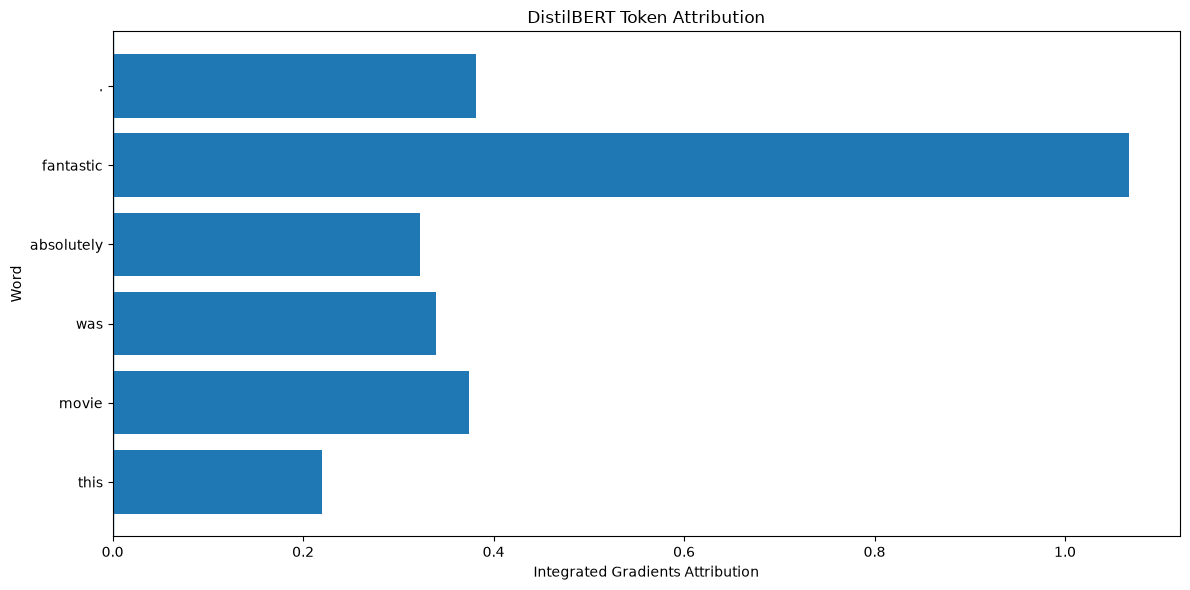

In [30]:
import matplotlib.pyplot as plt

# Plot word-level attributions
plt.figure(figsize=(12, 6))

plt.barh(
    words,
    scores
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Integrated Gradients Attribution")
plt.ylabel("Word")
plt.title("DistilBERT Token Attribution")

plt.tight_layout()
plt.show()

NEGATIVE EXAMPLE

In [65]:
negative_result = compare_attribution_stability(
    "This movie was terrible.",
    "This film was terrible."
)

print("Shared-word attribution comparison:")

for word, score_a, score_b in negative_result["comparison"]:
    print(
        f"{word:12} "
        f"{score_a:+.4f} → {score_b:+.4f}"
    )

print(
    "\nAttribution correlation:",
    f"{negative_result['correlation']:.4f}"
)

Shared-word attribution comparison:
.            +0.2327 → +0.3193
terrible     +0.9060 → +0.9193
this         +0.3512 → +0.3101
was          +0.1233 → +0.1043

Attribution correlation: 0.9873


# PLOT ATTRIBUTION VISUALIZATION:

In [ ]:
def plot_attributions(words, scores, title):
    """
    Plot word-level Integrated Gradients attributions.
    """

    # Sort words by attribution magnitude
    pairs = sorted(
        zip(words, scores),
        key=lambda x: abs(x[1])
    )

    plot_words = [x[0] for x in pairs]
    plot_scores = [x[1] for x in pairs]

    plt.figure(figsize=(12, 7))

    bars = plt.barh(
        plot_words,
        plot_scores
    )

    plt.axvline(
        0,
        linewidth=1
    )

    # Add attribution values to each bar
    for bar, score in zip(bars, plot_scores):
        offset = 0.01 if score >= 0 else -0.01

        plt.text(
            bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.3f}",
            va="center",
            ha="left" if score >= 0 else "right"
        )

    plt.xlabel("Integrated Gradients Attribution")
    plt.ylabel("Word")
    plt.title(title)

    plt.tight_layout()
    plt.show()

NEGATIVE

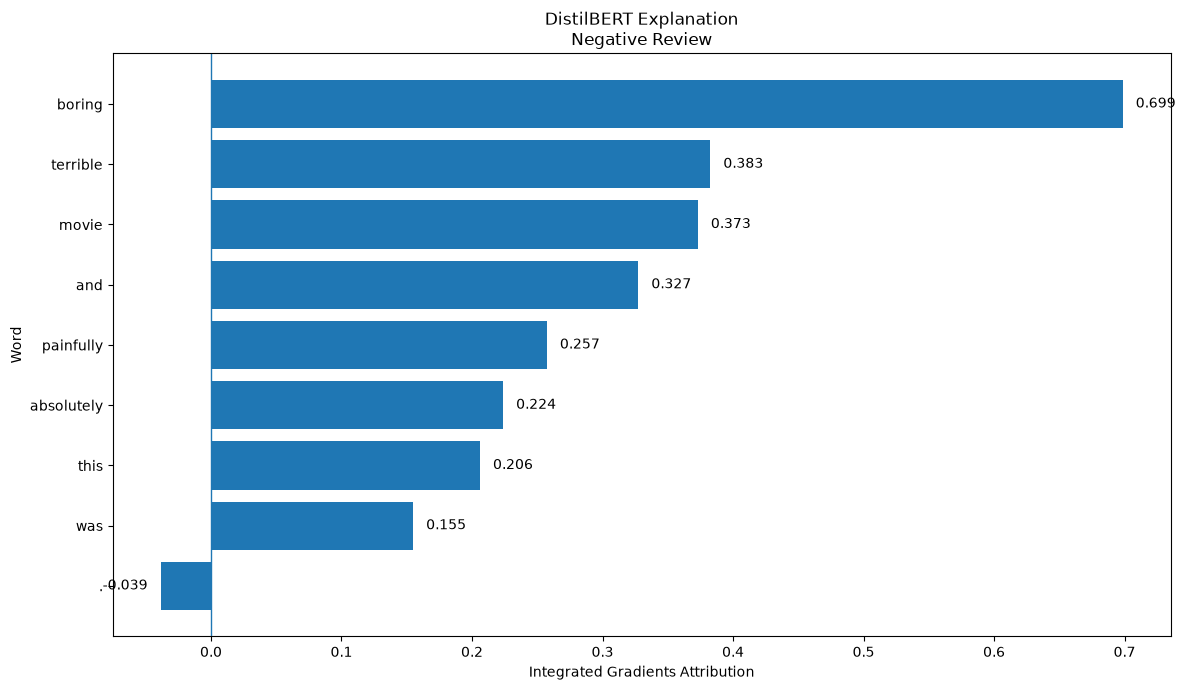

In [ ]:
negative_text = "This movie was absolutely terrible and painfully boring."

negative_words, negative_scores = get_word_attributions(
    negative_text
)

plot_attributions(
    negative_words,
    negative_scores,
    "DistilBERT Explanation\nNegative Review"
)

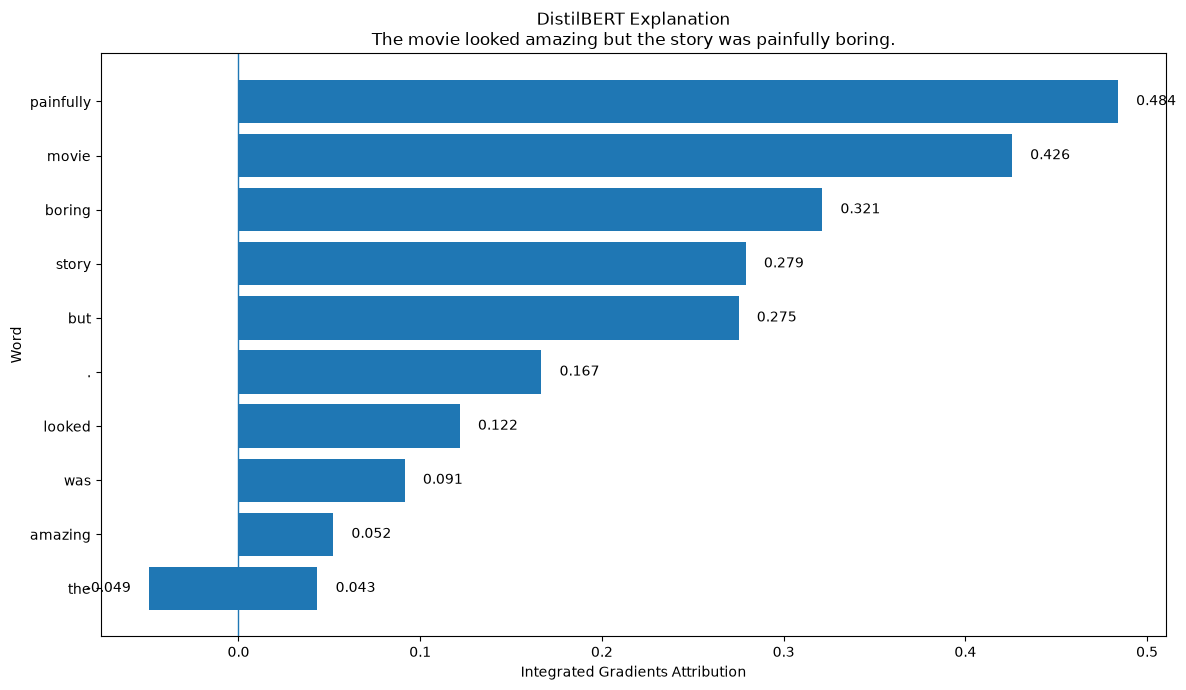

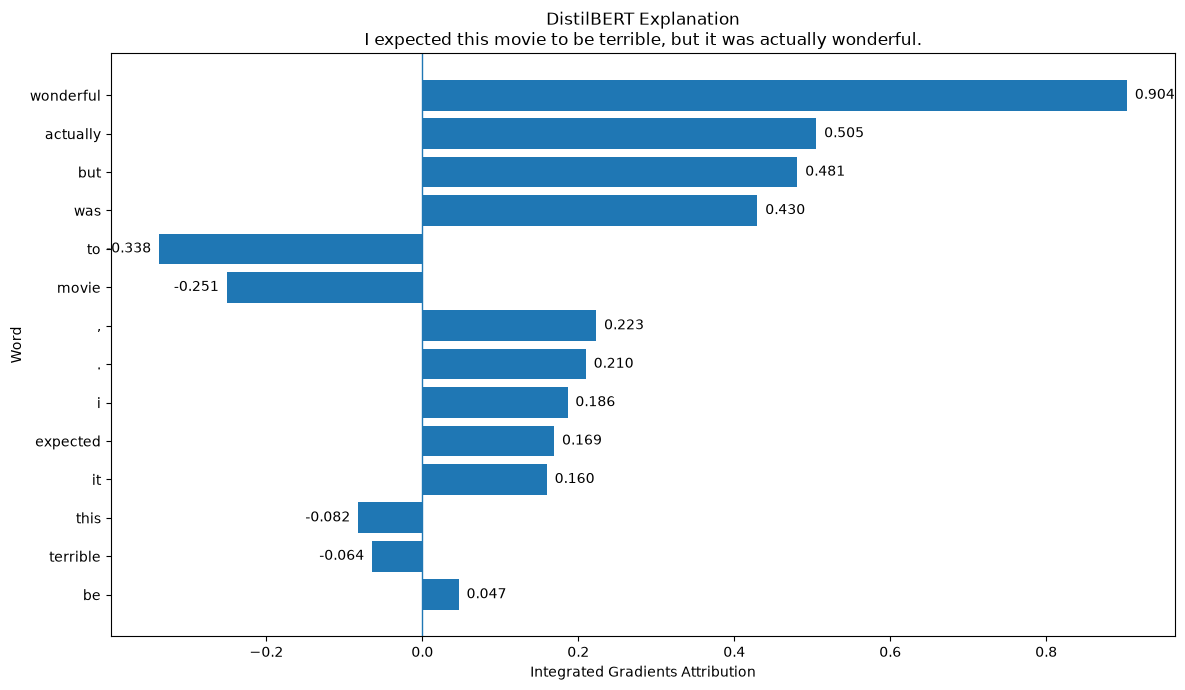

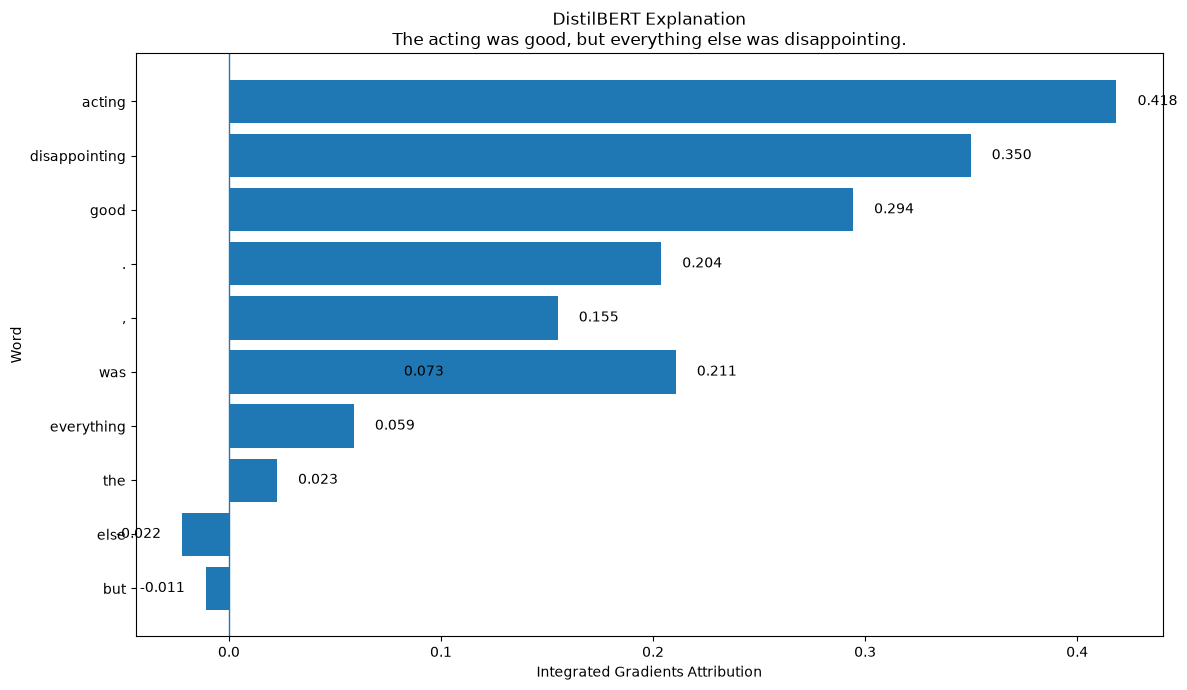

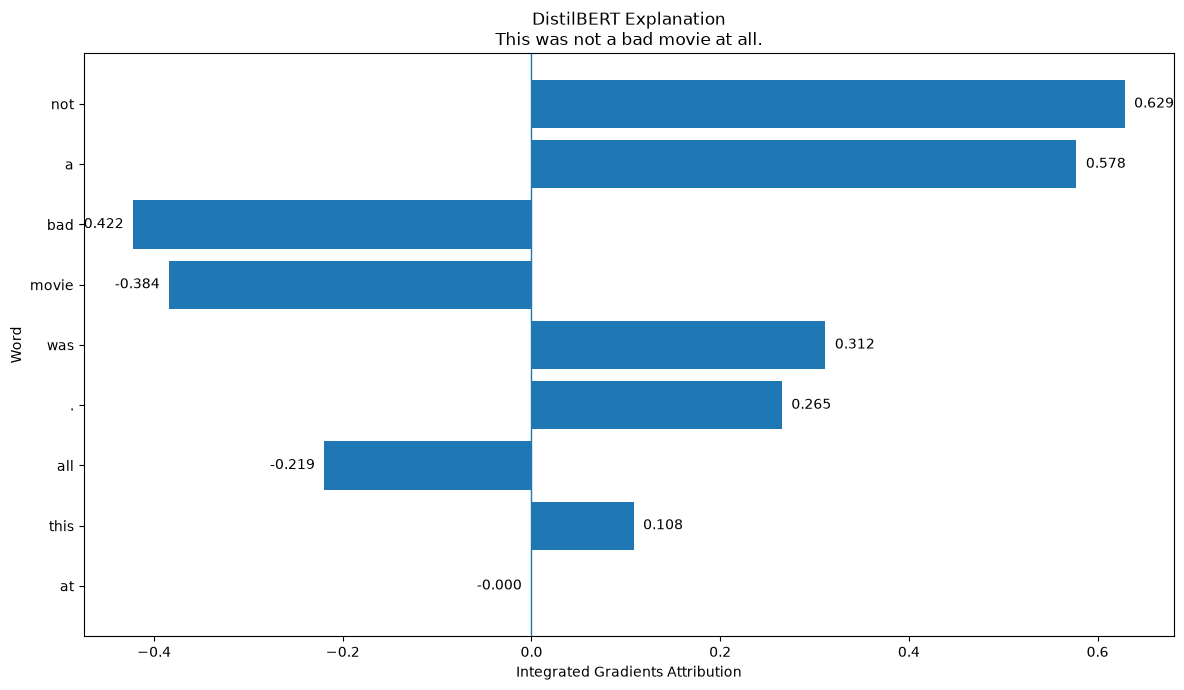

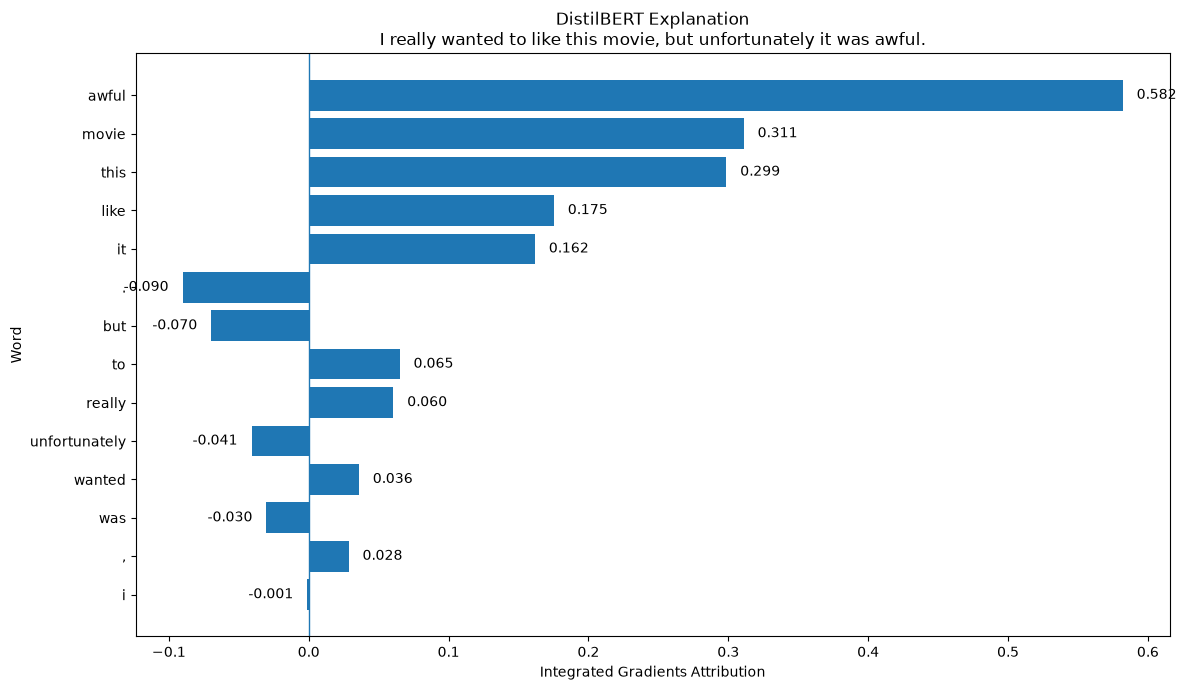

In [ ]:
test_texts = [
    "The movie looked amazing but the story was painfully boring.",
    "I expected this movie to be terrible, but it was actually wonderful.",
    "The acting was good, but everything else was disappointing.",
    "This was not a bad movie at all.",
    "I really wanted to like this movie, but unfortunately it was awful."
]


for text in test_texts:

    words, scores = get_word_attributions(
        text
    )

    plot_attributions(
        words,
        scores,
        f"DistilBERT Explanation\n{text}"
    )

# **CHANGE INPUT PRESERVE MEANING:**

If we slightly change the input while preserving its meaning, does the explanation remain reasonably stable?

In [ ]:
def get_word_attributions(text):
    """
    Generate word-level Integrated Gradients
    for a given input sentence.
    """

    (
        tokens,
        attributions,
        delta,
        input_output,
        baseline_output,
        total_attribution,
        completeness_error
    ) = interpreter.attribute(text)

    words, scores = interpreter.aggregate_tokens(
        tokens,
        attributions
    )

    return words, scores

In [ ]:
texts = [
    "This movie was fantastic.",
    "This film was fantastic.",
    "This movie was absolutely fantastic."
]

results = {}

for text in texts:

    words, scores = get_word_attributions(text)

    results[text] = {
        "words": words,
        "scores": scores
    }

    print("\n", text)

    for word, score in zip(words, scores):
        print(f"{word:15} {score:+.4f}")


 This movie was fantastic.
this            +0.3938
movie           +0.3064
was             +0.3228
fantastic       +1.2053
.               +0.3170

 This film was fantastic.
this            +0.2768
film            +0.3909
was             +0.3269
fantastic       +1.2137
.               +0.3466

 This movie was absolutely fantastic.
this            +0.2204
movie           +0.3744
was             +0.3391
absolutely      +0.3229
fantastic       +1.0673
.               +0.3815


In [ ]:
for text in texts:

    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True
    )

    encoding = {
        key: value.to(device)
        for key, value in encoding.items()
    }

    with torch.no_grad():
        outputs = model(**encoding)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    prediction = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[0, prediction].item()

    label = {
        0: "NEGATIVE",
        1: "POSITIVE"
    }[prediction]

    print(
        f"{label:8} "
        f"{confidence:.4f} | "
        f"{text}"
    )

POSITIVE 0.9910 | This movie was fantastic.
POSITIVE 0.9923 | This film was fantastic.
POSITIVE 0.9930 | This movie was absolutely fantastic.


In [ ]:
def compare_shared_attributions(result_a, result_b):
    """
    Compare attribution values for words
    appearing in both explanations.
    """

    words_a = result_a["words"]
    scores_a = result_a["scores"]

    words_b = result_b["words"]
    scores_b = result_b["scores"]

    scores_a = dict(zip(words_a, scores_a))
    scores_b = dict(zip(words_b, scores_b))

    shared_words = set(scores_a) & set(scores_b)

    comparisons = []

    for word in sorted(shared_words):
        comparisons.append(
            (
                word,
                scores_a[word],
                scores_b[word]
            )
        )

    return comparisons

In [ ]:
comparison = compare_shared_attributions(
    results[texts[0]],
    results[texts[1]]
)

print("Shared-word attribution comparison:")

for word, score_a, score_b in comparison:
    print(
        f"{word:12} "
        f"{score_a:+.4f} → {score_b:+.4f}"
    )

Shared-word attribution comparison:
.            +0.3170 → +0.3466
fantastic    +1.2053 → +1.2137
this         +0.3938 → +0.2768
was          +0.3228 → +0.3269


In [ ]:
import numpy as np

scores_a = [x[1] for x in comparison]
scores_b = [x[2] for x in comparison]

correlation = np.corrcoef(
    scores_a,
    scores_b
)[0, 1]

print(
    "Shared-word attribution correlation:",
    f"{correlation:.4f}"
)

Shared-word attribution correlation: 0.9894


# **WORD ATTRIBUTION CORRELATION FOR SEVERAL SENTENCE PAIRS**

In [ ]:
stability_pairs = [
    (
        "This movie was fantastic.",
        "This film was fantastic."
    ),
    (
        "This movie was terrible.",
        "This film was terrible."
    ),
    (
        "The acting was excellent.",
        "The performance was excellent."
    ),
    (
        "The story was extremely boring.",
        "The plot was extremely boring."
    ),
    (
        "This was a wonderful movie.",
        "This was an amazing movie."
    )
]

In [ ]:
stability_results = []

for text_a, text_b in stability_pairs:

    result = compare_attribution_stability(
        text_a,
        text_b
    )

    stability_results.append(result)

    print(
        f"Correlation: {result['correlation']:.4f}"
    )

    print(f"A: {text_a}")
    print(f"B: {text_b}")
    print()

Correlation: 0.9894
A: This movie was fantastic.
B: This film was fantastic.

Correlation: 0.9873
A: This movie was terrible.
B: This film was terrible.

Correlation: 0.7701
A: The acting was excellent.
B: The performance was excellent.

Correlation: 0.9902
A: The story was extremely boring.
B: The plot was extremely boring.

Correlation: 0.9832
A: This was a wonderful movie.
B: This was an amazing movie.



In [ ]:
for i, result in enumerate(stability_results, start=1):

    print(
        f"Pair {i}: "
        f"{result['correlation']:.4f}"
    )

Pair 1: 0.9894
Pair 2: 0.9873
Pair 3: 0.7701
Pair 4: 0.9902
Pair 5: 0.9832


In [ ]:
#MEAN STABILITY
correlations = [
    result["correlation"]
    for result in stability_results
]

mean_stability = np.mean(
    correlations
)

print(
    "Mean attribution correlation:",
    f"{mean_stability:.4f}"
)

Mean attribution correlation: 0.9441


In [ ]:
def plot_stability_comparison(result):
    """
    Visualize the shared-word attributions from
    an attribution stability comparison.
    """

    comparison = result["comparison"]

    words = [item[0] for item in comparison]
    scores_a = [item[1] for item in comparison]
    scores_b = [item[2] for item in comparison]

    # Plot Text A
    plot_attributions(
        words,
        scores_a,
        f"Text A\n{result['text_a']}"
    )

    # Plot Text B
    plot_attributions(
        words,
        scores_b,
        f"Text B\n{result['text_b']}"
    )

    print(
        "Attribution correlation:",
        f"{result['correlation']:.4f}"
    )

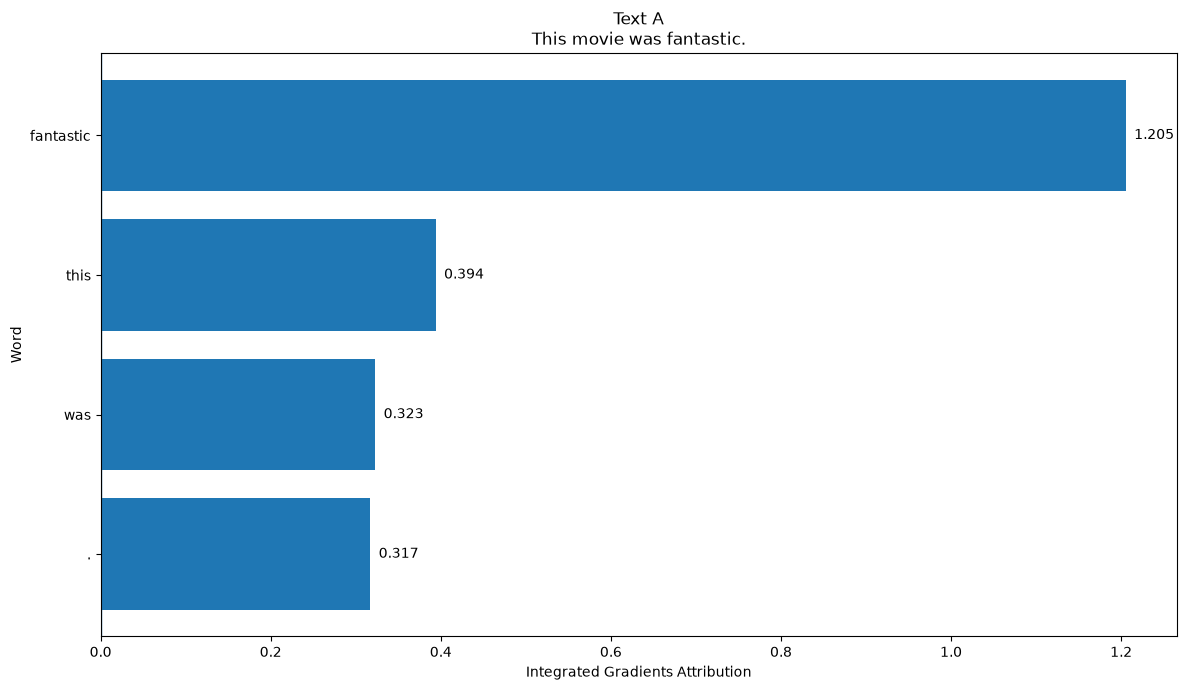

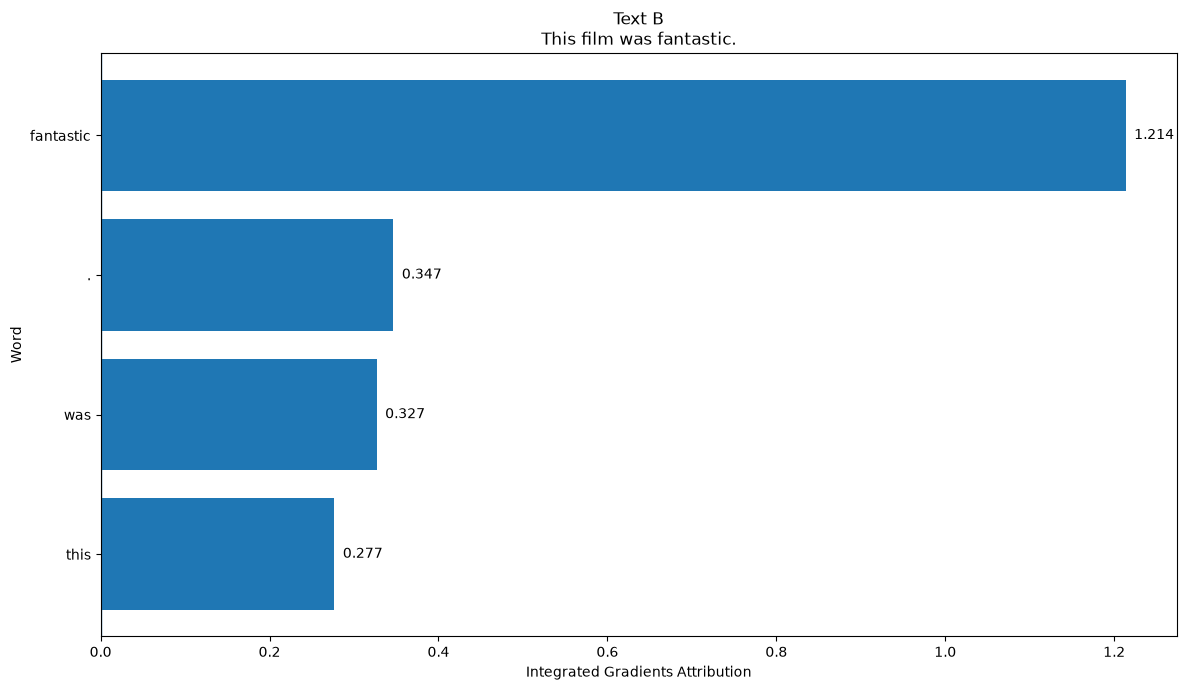

Attribution correlation: 0.9894


In [ ]:
positive_result = compare_attribution_stability(
    "This movie was fantastic.",
    "This film was fantastic."
)

plot_stability_comparison(
    positive_result
)

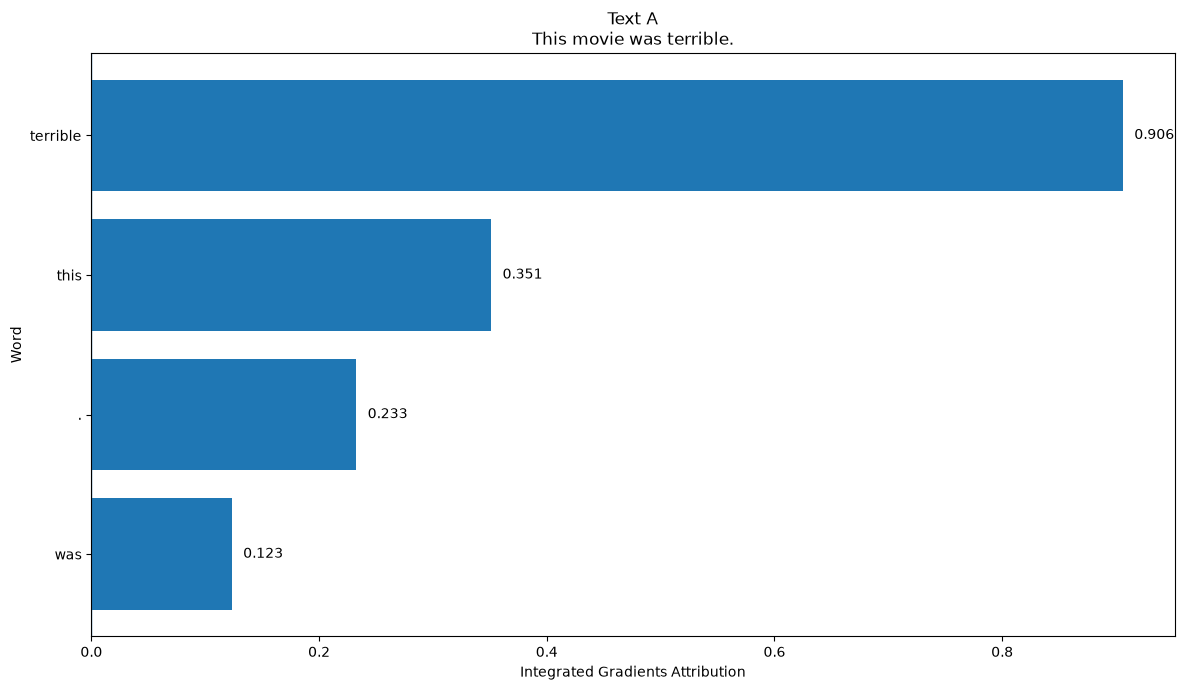

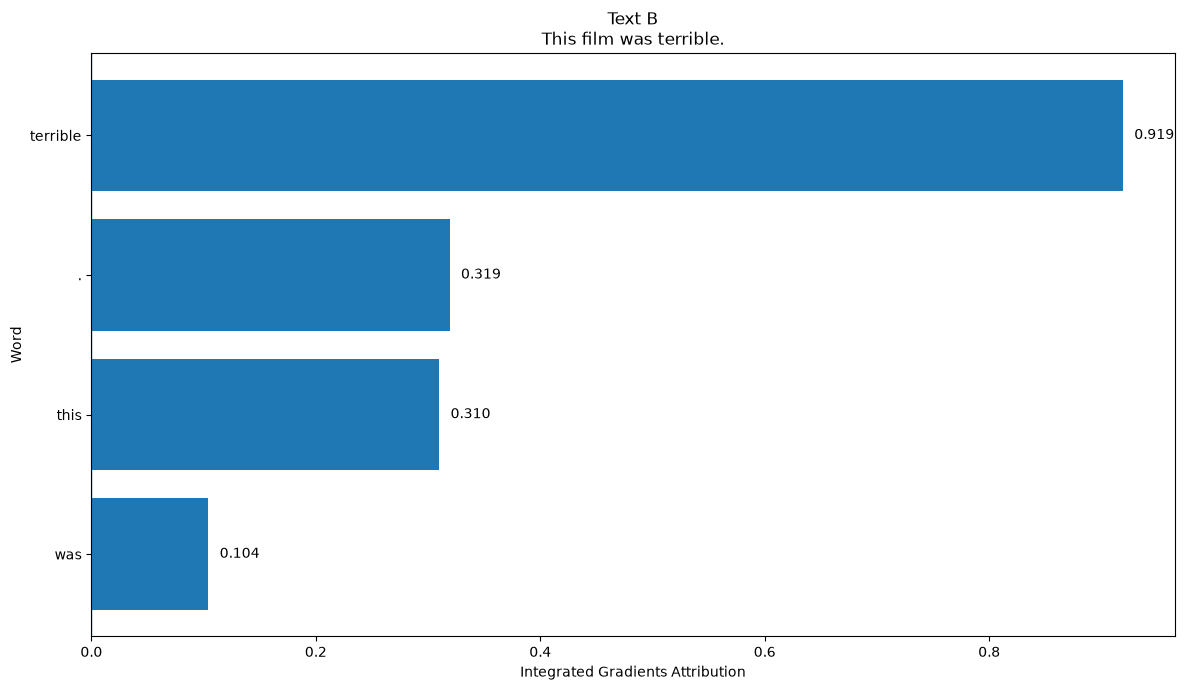

Attribution correlation: 0.9873


In [ ]:
negative_result = compare_attribution_stability(
    "This movie was terrible.",
    "This film was terrible."
)

plot_stability_comparison(
    negative_result
)

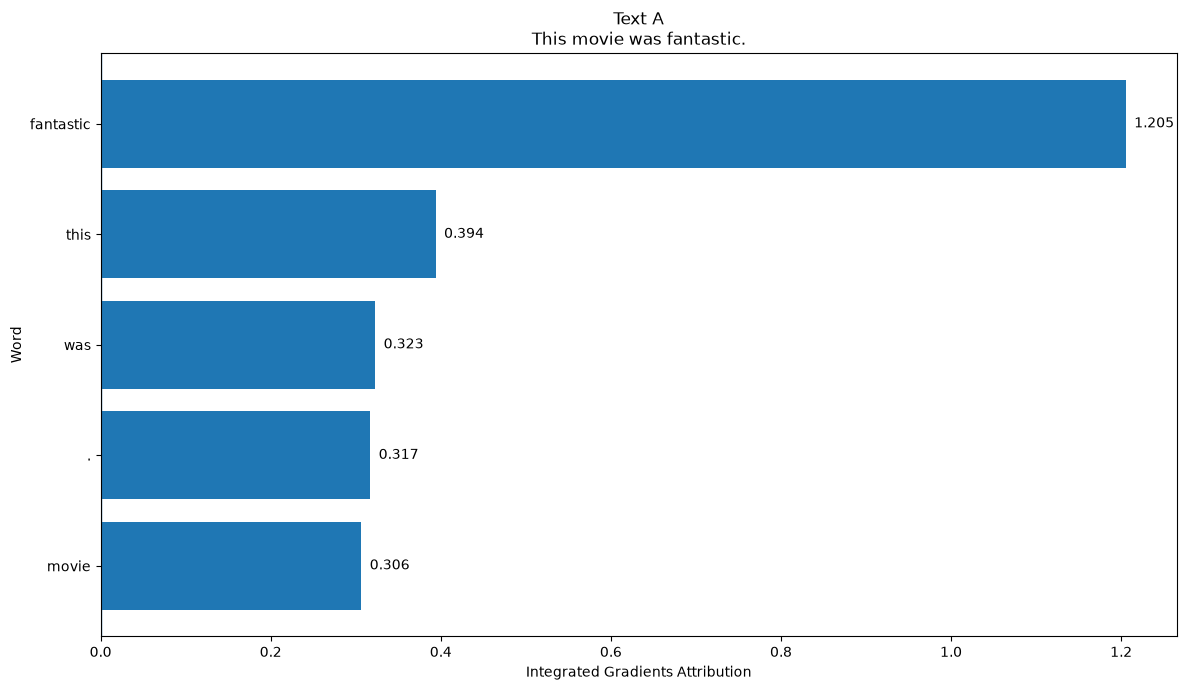

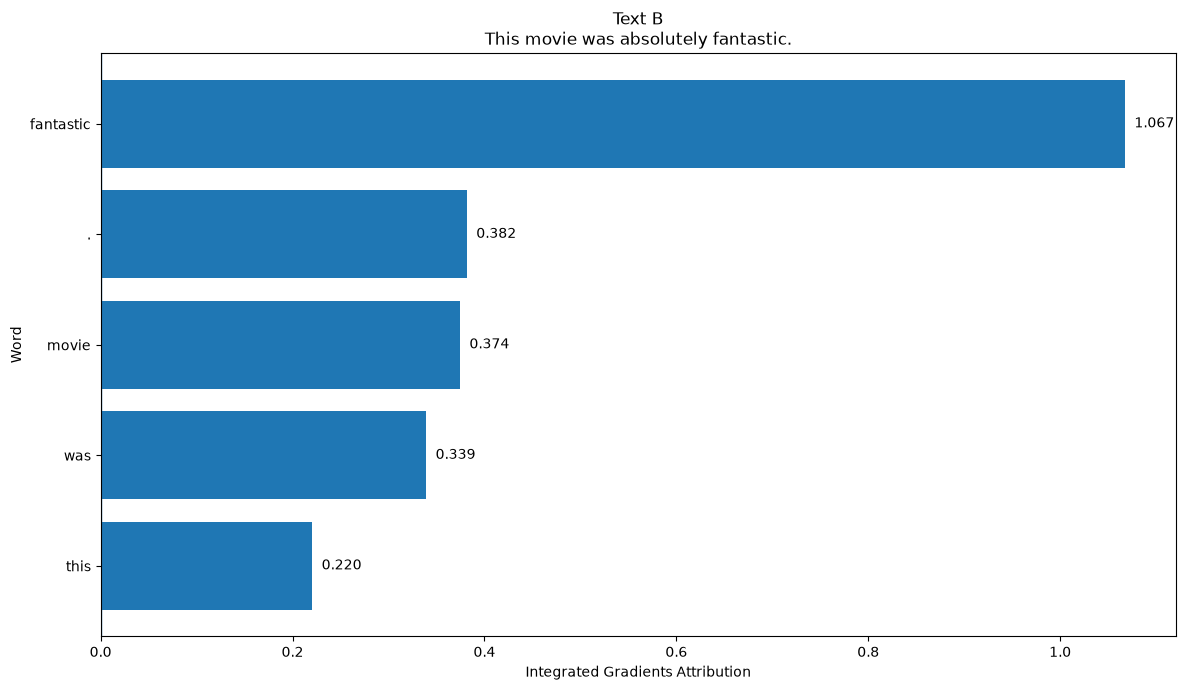

Attribution correlation: 0.9609


In [ ]:
modifier_result = compare_attribution_stability(
    "This movie was fantastic.",
    "This movie was absolutely fantastic."
)

plot_stability_comparison(
    modifier_result
)

# **CONFIDENCE VS ATTRIBUTION EXPERIMENT**

In [ ]:
confidence_test_texts = [
    # Clearly positive
    "This movie was absolutely fantastic and I loved every minute of it.",

    # Clearly negative
    "This movie was terrible, boring, and completely disappointing.",

    # Mixed sentiment
    "The acting was excellent, but the story was painfully boring.",

    # Negation
    "This was not a bad movie at all.",

    # Strong negation
    "I did not enjoy this movie and I would never watch it again.",

    # Positive despite negative word
    "I expected this movie to be terrible, but it was actually wonderful.",

    # Negative despite positive word
    "The movie looked amazing, but the story was awful.",

    # Ambiguous
    "The movie was okay and had some good moments.",

    # Sarcasm-like
    "What a fantastic movie... if you enjoy falling asleep.",

    # More subtle
    "The movie had impressive visuals, although the overall experience felt disappointing."
]

MODEL PREDICTIONS:

In [ ]:
import torch

def get_prediction_and_confidence(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probs, dim=-1).item()
    confidence = probs[0, predicted_class].item()

    return predicted_class, confidence

In [ ]:
for text in confidence_test_texts:
    pred, conf = get_prediction_and_confidence(text)

    label = "POSITIVE" if pred == 1 else "NEGATIVE"

    print(f"{conf:.4f} | {label} | {text}")

0.9959 | POSITIVE | This movie was absolutely fantastic and I loved every minute of it.
0.9972 | NEGATIVE | This movie was terrible, boring, and completely disappointing.
0.9785 | NEGATIVE | The acting was excellent, but the story was painfully boring.
0.8251 | POSITIVE | This was not a bad movie at all.
0.9706 | NEGATIVE | I did not enjoy this movie and I would never watch it again.
0.9860 | POSITIVE | I expected this movie to be terrible, but it was actually wonderful.
0.9947 | NEGATIVE | The movie looked amazing, but the story was awful.
0.7693 | POSITIVE | The movie was okay and had some good moments.
0.9895 | POSITIVE | What a fantastic movie... if you enjoy falling asleep.
0.7146 | NEGATIVE | The movie had impressive visuals, although the overall experience felt disappointing.


Attribution results for selected indices

In [ ]:
selected_indices = [0, 3, 2, 8]

attribution_results = []

for i in selected_indices:

    text = confidence_test_texts[i]

    pred, confidence = get_prediction_and_confidence(text)

    words, attributions = get_word_attributions(text)

    attribution_results.append({
        "text": text,
        "prediction": pred,
        "confidence": confidence,
        "words": words,
        "attributions": attributions
    })

    print("\n" + "=" * 80)
    print(f"Confidence: {confidence:.4f}")
    print(f"Prediction: {'POSITIVE' if pred == 1 else 'NEGATIVE'}")
    print(text)

    print("\nAttributions:")
    for word, score in zip(words, attributions):
        print(f"{word:15s} {score:+.4f}")


Confidence: 0.9959
Prediction: POSITIVE
This movie was absolutely fantastic and I loved every minute of it.

Attributions:
this            +0.2173
movie           +0.1484
was             +0.0455
absolutely      +0.2343
fantastic       +0.4728
and             +0.4272
i               +0.2173
loved           +0.4856
every           +0.0386
minute          +0.0146
of              +0.0572
it              +0.2296
.               +0.2258

Confidence: 0.8251
Prediction: POSITIVE
This was not a bad movie at all.

Attributions:
this            +0.1083
was             +0.3115
not             +0.6287
a               +0.5776
bad             -0.4222
movie           -0.3839
at              -0.0002
all             -0.2195
.               +0.2654

Confidence: 0.9785
Prediction: NEGATIVE
The acting was excellent, but the story was painfully boring.

Attributions:
the             -0.1265
acting          +0.3120
was             -0.0059
excellent       -0.0986
,               +0.1561
but             -0.01

# **ATTRIBUTION CONCENTRATION SCORE:**

In [ ]:
def attribution_concentration(attributions, top_k=3):
    values = [abs(float(x)) for x in attributions]

    total = sum(values)

    if total == 0:
        return 0.0

    top_values = sorted(values, reverse=True)[:top_k]

    return sum(top_values) / total

In [ ]:
for result in attribution_results:

    concentration = attribution_concentration(
        result["attributions"]
    )

    print(
        f"Confidence: {result['confidence']:.4f} | "
        f"Concentration: {concentration:.4f} | "
        f"{result['text']}"
    )

Confidence: 0.9959 | Concentration: 0.4924 | This movie was absolutely fantastic and I loved every minute of it.
Confidence: 0.8251 | Concentration: 0.5582 | This was not a bad movie at all.
Confidence: 0.9785 | Concentration: 0.5310 | The acting was excellent, but the story was painfully boring.
Confidence: 0.9895 | Concentration: 0.5338 | What a fantastic movie... if you enjoy falling asleep.


# **PREDICTION CORRECTNESS:**

GROUND TRUTH LABELS

In [69]:
ground_truth = {
    "This movie was absolutely fantastic and I loved every minute of it.": 1,
    "This was not a bad movie at all.": 1,
    "The acting was excellent, but the story was painfully boring.": 0,
    "What a fantastic movie... if you enjoy falling asleep.": 0
}

In [70]:
for result in attribution_results:

    text = result["text"]

    true_label = ground_truth[text]
    predicted_label = result["prediction"]

    concentration = attribution_concentration(
        result["attributions"]
    )

    correct = true_label == predicted_label

    print(
        f"Confidence: {result['confidence']:.4f} | "
        f"Concentration: {concentration:.4f} | "
        f"Correct: {correct} | "
        f"{text}"
    )

Confidence: 0.9959 | Concentration: 0.4924 | Correct: True | This movie was absolutely fantastic and I loved every minute of it.
Confidence: 0.8251 | Concentration: 0.5582 | Correct: True | This was not a bad movie at all.
Confidence: 0.9785 | Concentration: 0.5310 | Correct: True | The acting was excellent, but the story was painfully boring.
Confidence: 0.9895 | Concentration: 0.5338 | Correct: False | What a fantastic movie... if you enjoy falling asleep.


In [71]:
remaining_indices = [1, 4, 5, 6, 7, 9]

for i in remaining_indices:

    text = confidence_test_texts[i]

    pred, confidence = get_prediction_and_confidence(text)

    words, attributions = get_word_attributions(text)

    concentration = attribution_concentration(attributions)

    print("\n" + "=" * 80)
    print(f"Confidence: {confidence:.4f}")
    print(f"Prediction: {'POSITIVE' if pred == 1 else 'NEGATIVE'}")
    print(f"Concentration: {concentration:.4f}")
    print(text)

    print("\nTop attributions:")

    pairs = list(zip(words, attributions))

    # Sort by absolute attribution magnitude
    pairs = sorted(
        pairs,
        key=lambda x: abs(float(x[1])),
        reverse=True
    )

    for word, score in pairs[:5]:
        print(f"{word:15s} {float(score):+.4f}")


Confidence: 0.9972
Prediction: NEGATIVE
Concentration: 0.4969
This movie was terrible, boring, and completely disappointing.

Top attributions:
disappointing   +0.4411
terrible        +0.4202
boring          +0.3747
movie           +0.3045
completely      +0.2497

Confidence: 0.9706
Prediction: NEGATIVE
Concentration: 0.6258
I did not enjoy this movie and I would never watch it again.

Top attributions:
enjoy           +0.4364
movie           +0.3586
never           +0.2517
this            +0.1196
i               +0.1118

Confidence: 0.9860
Prediction: POSITIVE
Concentration: 0.4667
I expected this movie to be terrible, but it was actually wonderful.

Top attributions:
wonderful       +0.9037
actually        +0.5053
but             +0.4810
was             +0.4297
to              -0.3376

Confidence: 0.9947
Prediction: NEGATIVE
Concentration: 0.6404
The movie looked amazing, but the story was awful.

Top attributions:
awful           +0.8324
movie           +0.4177
story           +0.2